# Tech Challenge - Fase 2
## Classificacao da qualidade de vinhos (Wine Quality Dataset)

Pos-graduacao FIAP/POSTECH

---

Este notebook desenvolve um **modelo de classificacao binaria** para prever se um vinho e de **alta qualidade** (nota sensorial >= 7) ou de **baixa/media qualidade** (nota < 7), a partir de 11 variaveis fisico-quimicas.

O pipeline segue as etapas: (1) Compreensao do problema, (2) Analise Exploratoria de Dados, (3) Pre-processamento, (4) Modelagem, (5) Avaliacao e (6) Interpretacao dos resultados.

As funcoes reutilizaveis (carregamento, pre-processamento, modelagem e avaliacao) ficam nos modulos em `src/`, mantendo o notebook focado na narrativa da analise.

## 0. Configuracao do ambiente

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Localiza a raiz do projeto (funciona a partir de notebooks/ ou da raiz do repo)
def _find_project_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(6):
        if (p / 'src').exists() and (p / 'data').exists():
            return p
        p = p.parent
    return start.resolve()

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Modulos auxiliares do projeto
from src import preprocessing as prep
from src import eda
from src import modeling as mdl
from src import evaluation as ev

DATA_PATH = PROJECT_ROOT / 'data' / 'WineQT.csv'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline
eda.set_plot_style()

print('Raiz do projeto:', PROJECT_ROOT)
print('Dataset:', DATA_PATH.name, '| existe:', DATA_PATH.exists())
print('Pasta de resultados:', RESULTS_DIR)

Raiz do projeto: C:\Users\letic\OneDrive\Documentos\Pós Graduação - FIAP\FASE 2\TechChallenge_Fase_2
Dataset: WineQT.csv | existe: True
Pasta de resultados: C:\Users\letic\OneDrive\Documentos\Pós Graduação - FIAP\FASE 2\TechChallenge_Fase_2\results


## 1. Compreensao do problema

O **Wine Quality Dataset** reune medidas laboratoriais (fisico-quimicas) de amostras de vinho tinto, cada uma avaliada sensorialmente por especialistas e resumida em uma nota de **qualidade de 0 a 10** (mediana das avaliacoes). As 11 variaveis preditoras sao:

| Variavel | Significado enologico |
|---|---|
| fixed acidity | Acidez fixa (acidos nao volateis, ex. tartarico) |
| volatile acidity | Acidez volatil (acido acetico) - em excesso da gosto de vinagre |
| citric acid | Acido citrico - da frescor e sabor |
| residual sugar | Acucar residual apos a fermentacao |
| chlorides | Cloretos (sal) |
| free sulfur dioxide | SO2 livre - protege contra oxidacao/microrganismos |
| total sulfur dioxide | SO2 total (livre + ligado) |
| density | Densidade (relacionada a acucar e alcool) |
| pH | Acidez/alcalinidade |
| sulphates | Sulfatos - aditivo antimicrobiano/antioxidante |
| alcohol | Teor alcoolico (% vol.) |

### Variavel alvo

O problema original e multiclasse (nota de 0 a 10), mas aqui o reformulamos como **classificacao binaria**, mais util para controle de qualidade:

$$ \text{high\_quality} = \begin{cases} 1 & \text{se } quality \geq 7 \ (\text{alta qualidade}) \\ 0 & \text{se } quality < 7 \ (\text{baixa/media qualidade}) \end{cases} $$

A coluna original `quality` e **preservada**. O objetivo de negocio e **identificar vinhos de alta qualidade a partir de medidas de laboratorio**, apoiando decisoes de producao e selecao.

In [2]:
# Carrega os dados (a funcao ja remove a coluna 'Id', que e apenas um identificador)
df_raw = prep.load_data(str(DATA_PATH))
df_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Estrutura, tipos e memoria
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [4]:
# Estatisticas descritivas (transpostas para facilitar a leitura)
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


**Observacoes da estrutura:** sao 1143 amostras e 11 variaveis numericas + `quality`. As escalas sao muito diferentes entre si (ex.: `total sulfur dioxide` na casa das dezenas vs `density` proxima de 1), o que **justifica a padronizacao** antes de modelos sensiveis a escala. As medias/medianas e min/max ja sugerem **assimetria e possiveis outliers** em varias variaveis.

In [5]:
# Cria a variavel alvo binaria (preservando 'quality') e avalia qualidade dos dados
df = prep.create_binary_target(df_raw, threshold=7)

print('Distribuicao de quality (nota original):')
print(df['quality'].value_counts().sort_index())

print('\nDistribuicao de high_quality (alvo binario, >= 7):')
print(df['high_quality'].value_counts().sort_index())

n_missing = int(df.isna().sum().sum())
n_dup = int(df_raw.duplicated().sum())
print(f'\nValores faltantes no dataset: {n_missing}')
print(f'Linhas exatamente duplicadas: {n_dup}')

Distribuicao de quality (nota original):
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Distribuicao de high_quality (alvo binario, >= 7):
high_quality
0    984
1    159
Name: count, dtype: int64

Valores faltantes no dataset: 0
Linhas exatamente duplicadas: 125


**Compreensao do problema - conclusoes:**

- A variavel alvo `high_quality` foi criada preservando a nota original `quality`.
- **Nao ha valores faltantes** (0 nulos).
- Existem **125 linhas exatamente duplicadas**, que serao removidas no pre-processamento para evitar vazamento entre treino e teste (registros identicos nos dois conjuntos inflariam a metrica).
- Ja se percebe **forte desbalanceamento**: a classe de alta qualidade e minoritaria (apenas ~14% das amostras) - fato central para as decisoes de split, balanceamento e metricas.

## 2. Analise Exploratoria de Dados (EDA)

Exploramos as **11 variaveis fisico-quimicas originais** e sua relacao com o alvo, antes de qualquer transformacao. Todos os graficos sao salvos em `results/` como PNG.

### 2.1 Distribuicao das variaveis (histogramas)

Grafico salvo em: results\eda_histogramas.png


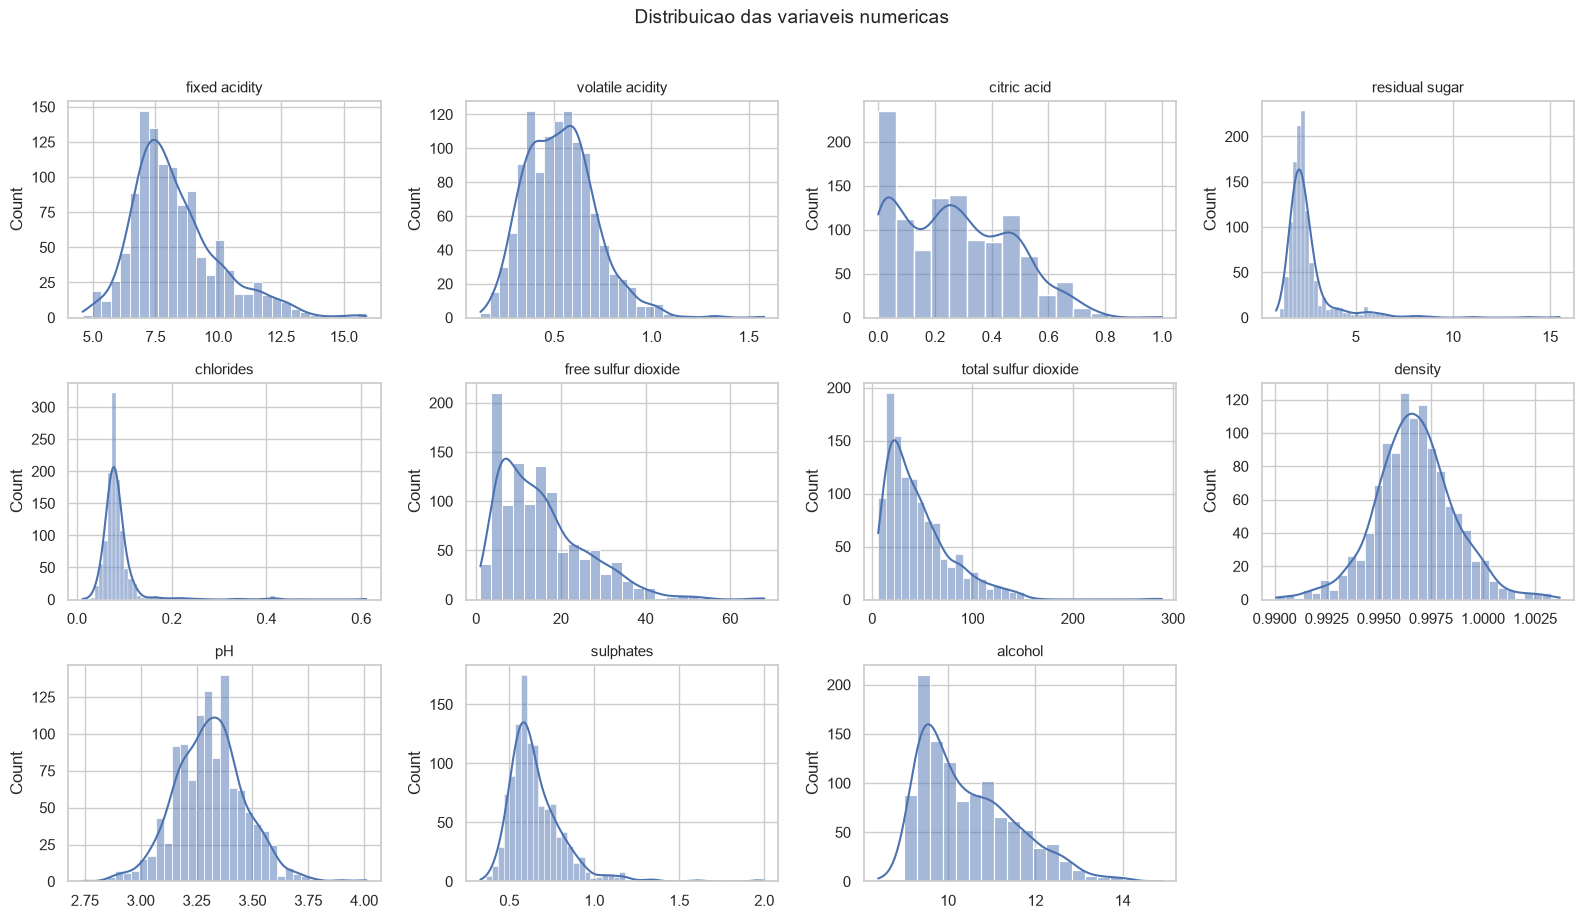

In [6]:
path = eda.plot_feature_histograms(df, prep.ORIGINAL_FEATURES, RESULTS_DIR)
print('Grafico salvo em:', path.relative_to(PROJECT_ROOT))

**Leitura:** varias variaveis sao **assimetricas a direita** (cauda longa) - notadamente `residual sugar`, `chlorides`, `sulphates`, `total/free sulfur dioxide` e, em menor grau, `fixed acidity` e `alcohol`. `density` e `pH` sao aproximadamente simetricas. Essa assimetria, somada aos outliers vistos adiante, reforca o uso de **padronizacao** e **capping de outliers**.

### 2.2 Matriz de correlacao

alcohol                 0.404
citric acid             0.251
sulphates               0.208
fixed acidity           0.123
residual sugar          0.064
free sulfur dioxide    -0.056
pH                     -0.073
chlorides              -0.104
total sulfur dioxide   -0.113
density                -0.149
volatile acidity       -0.305
Name: high_quality, dtype: float64

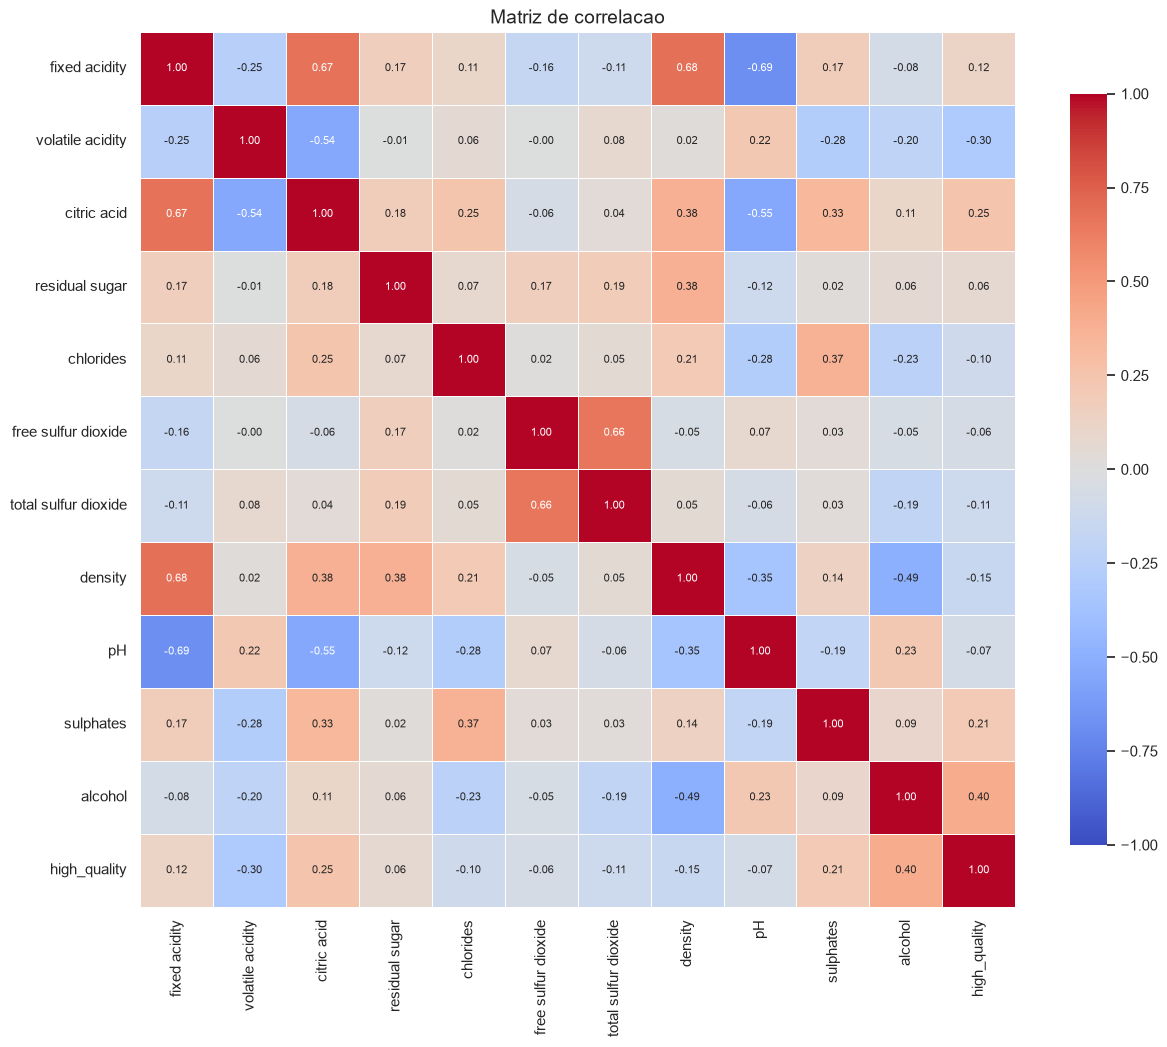

In [7]:
corr = eda.plot_correlation_heatmap(df, prep.ORIGINAL_FEATURES + ['high_quality'], RESULTS_DIR)
# Correlacao de cada variavel com o alvo (ordenada)
corr['high_quality'].drop('high_quality').sort_values(ascending=False).round(3)

**Interpretacao (relacao com o processo de vinificacao):**

Correlacoes **positivas** com a alta qualidade:
- **alcohol (+):** o maior impulsionador. Uvas mais maduras geram mais alcool; vinhos mais encorpados tendem a ser melhor avaliados.
- **sulphates (+):** atuam como antimicrobiano/antioxidante; boa dosagem preserva o vinho.
- **citric acid (+):** contribui para frescor e complexidade aromatica.

Correlacoes **negativas** com a alta qualidade:
- **volatile acidity (-):** principal indicador de defeito - excesso de acido acetico da gosto de vinagre e derruba a nota.
- **density (-):** correlacionada a acucar/alcool; menor densidade acompanha maior teor alcoolico.
- **chlorides / total sulfur dioxide (-):** excesso de sal ou de SO2 gera sabores indesejados.

Entre variaveis: `fixed acidity` se correlaciona negativamente com `pH` (mais acido -> menor pH) e positivamente com `citric acid` e `density`; `free` e `total sulfur dioxide` andam juntos. Isso indica **redundancia parcial**, que as features derivadas (razoes) ajudam a resumir.

### 2.3 Boxplots e outliers

Grafico salvo em: results\eda_boxplots.png


,n_outliers_IQR
residual sugar,110
chlorides,77
fixed acidity,44
sulphates,43
total sulfur dioxide,40
density,36
pH,20
free sulfur dioxide,18
volatile acidity,14
alcohol,12


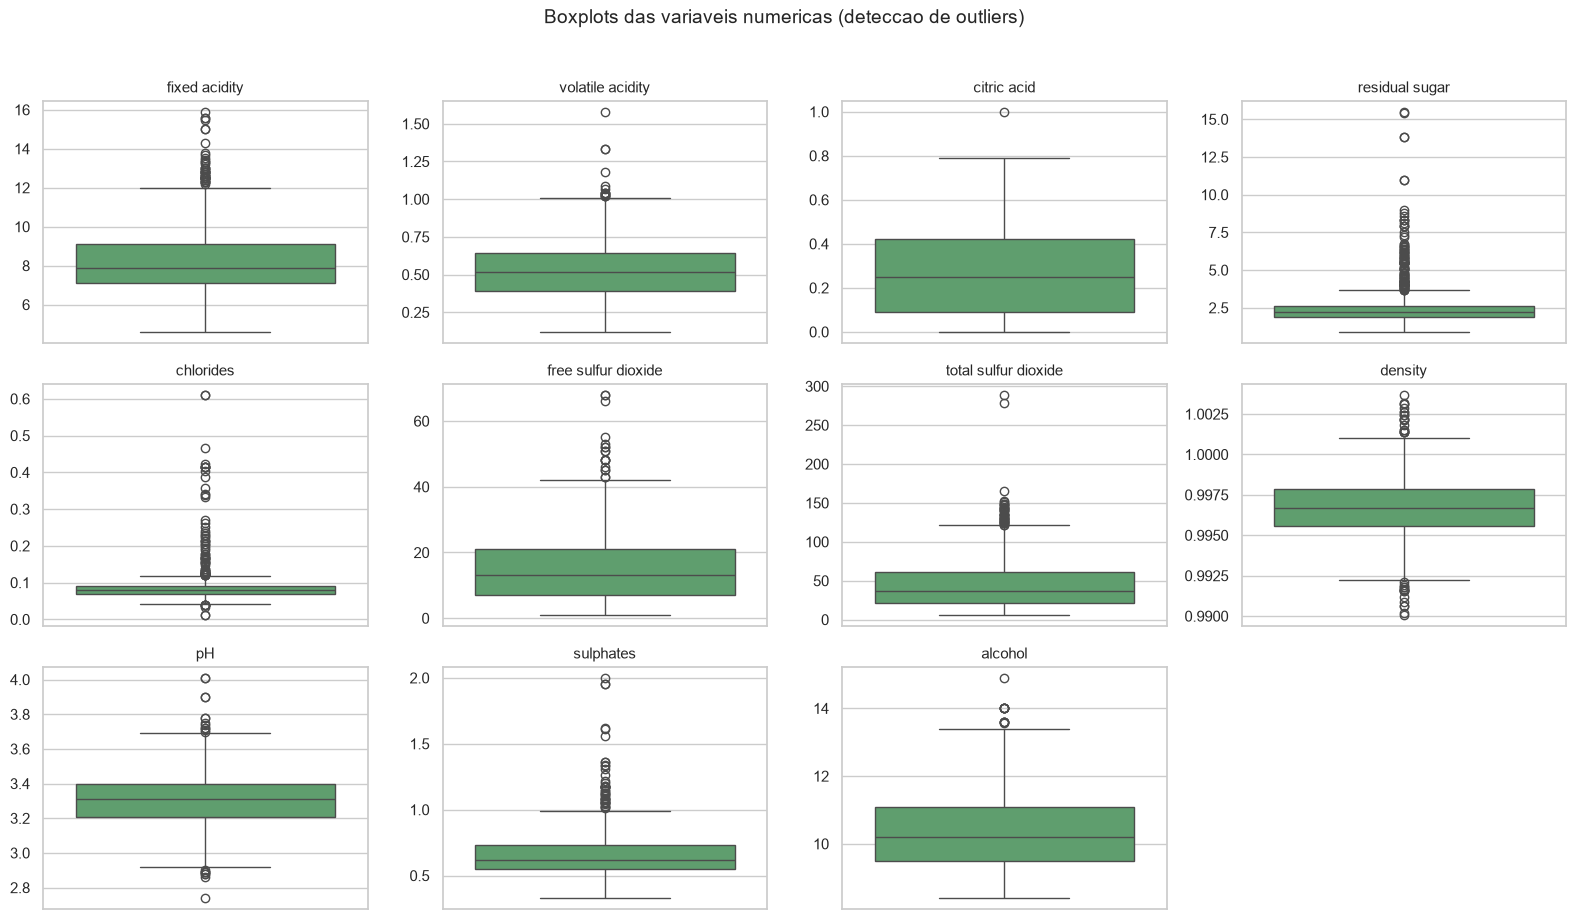

In [ ]:
path = eda.plot_boxplots(df, prep.ORIGINAL_FEATURES, RESULTS_DIR)
print('Grafico salvo em:', path.relative_to(PROJECT_ROOT))

# Contagem de outliers pelo criterio IQR (1.5x) em cada variavel
prep.count_outliers(df, prep.ORIGINAL_FEATURES).to_frame('n_outliers_IQR')

**Leitura:** `residual sugar`, `chlorides`, `sulphates` e `total sulfur dioxide` concentram muitos pontos fora do criterio IQR. Sao, muito provavelmente, **variacoes quimicas legitimas** (nao erros de digitacao). Por isso, no pre-processamento optamos por **capping (winsorizacao)** em vez de remover linhas - preservando o tamanho da amostra e, principalmente, a rara classe positiva.

### 2.4 Variaveis por classe

Grafico salvo em: results\eda_boxplots_por_classe.png


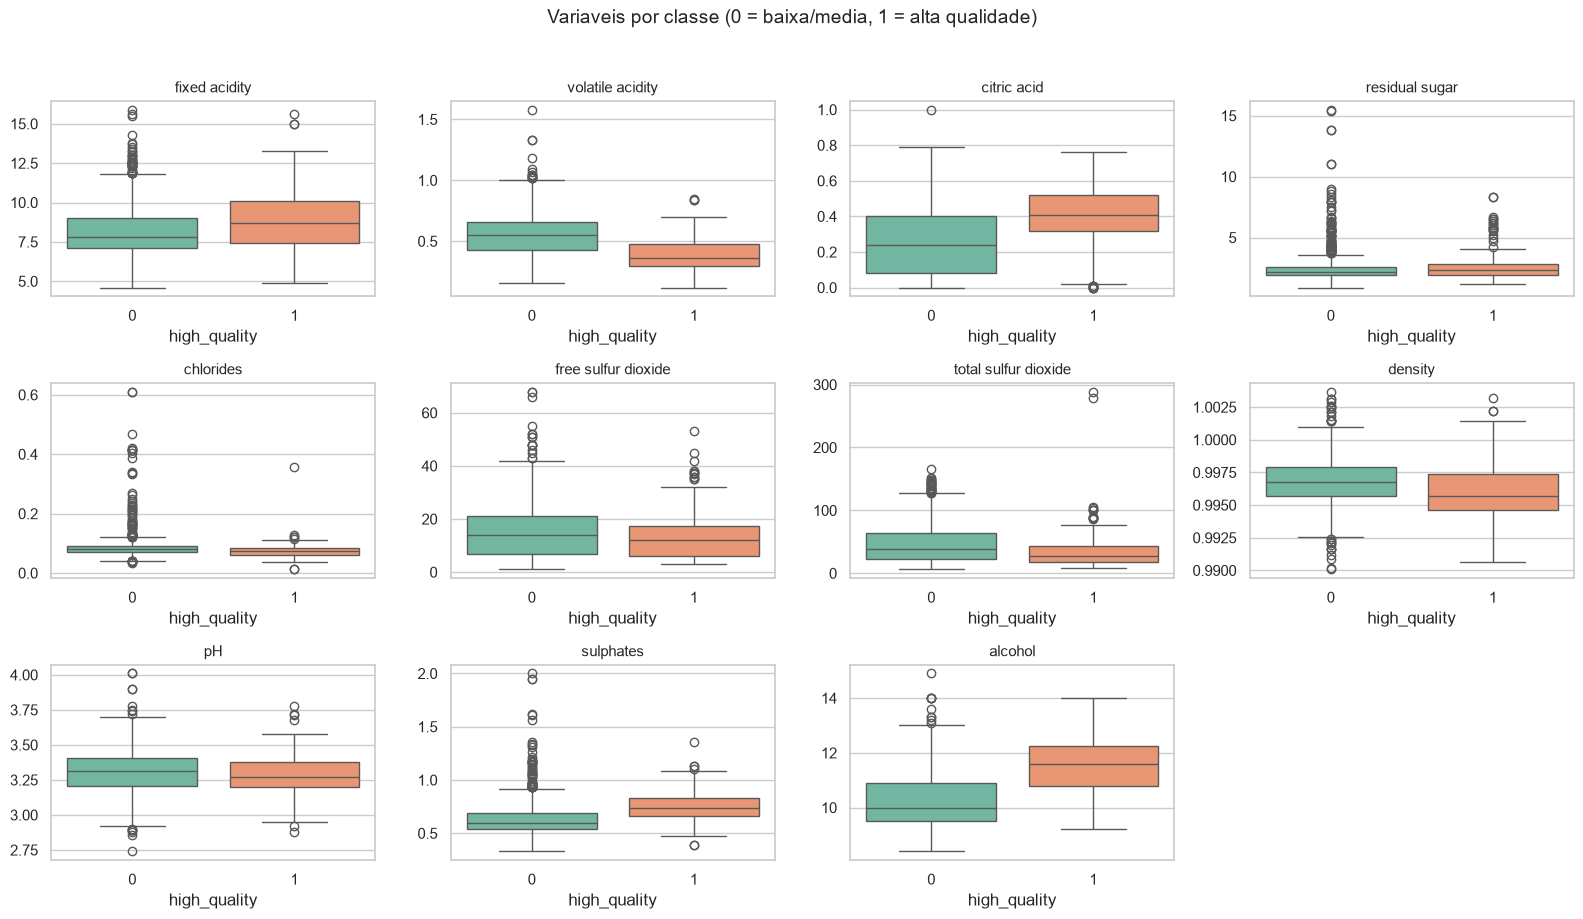

In [9]:
path = eda.plot_boxplots_by_target(df, prep.ORIGINAL_FEATURES, 'high_quality', RESULTS_DIR)
print('Grafico salvo em:', path.relative_to(PROJECT_ROOT))

**Leitura:** os vinhos de **alta qualidade** (classe 1) apresentam, em geral, **maior** `alcohol`, `sulphates` e `citric acid`, e **menor** `volatile acidity` e `density`. Isso confirma visualmente o que a matriz de correlacao indicou e antecipa quais variaveis os modelos devem considerar mais importantes.

### 2.5 Balanceamento das classes

Classe 0 (baixa/media): 984
Classe 1 (alta qualidade): 159
Proporcao de alta qualidade: 13.9%
Razao de desbalanceamento (neg:pos): 6.2 : 1


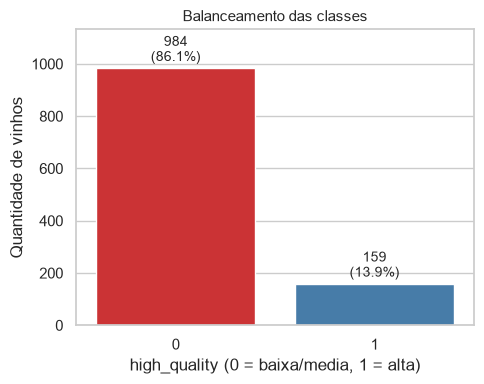

In [10]:
counts = eda.plot_class_balance(df, 'high_quality', RESULTS_DIR)
pos = int(counts.get(1, 0)); neg = int(counts.get(0, 0))
print(f'Classe 0 (baixa/media): {neg}')
print(f'Classe 1 (alta qualidade): {pos}')
print(f'Proporcao de alta qualidade: {pos / (pos + neg):.1%}')
print(f'Razao de desbalanceamento (neg:pos): {neg / pos:.1f} : 1')

**Conclusao sobre o balanceamento:** apenas ~14% das amostras sao de alta qualidade (**razao ~6:1**) - um **desbalanceamento significativo**. Consequencias para o restante do pipeline:
- **split estratificado** pela variavel alvo;
- **estrategia de balanceamento** (class_weight/scale_pos_weight, com SMOTE como comparacao);
- **metricas** alem da acuracia (precision, recall, F1, AUC-ROC e AUC-PR), pois um modelo trivial que preveja sempre 'baixa/media' ja acertaria ~86%.

### Resumo da EDA

- **1143 amostras, 11 variaveis fisico-quimicas**, sem valores faltantes; **125 duplicatas** a remover.
- Distribuicoes **assimetricas** e com **outliers** (residual sugar, chlorides, sulphates, SO2).
- Principais correlacoes com qualidade: **alcohol (+)**, **sulphates (+)**, **citric acid (+)**, **volatile acidity (-)**, **density (-)**.
- **Desbalanceamento ~6:1** (14% de alta qualidade) - direciona split, balanceamento e metricas.
- Proximos passos: pre-processamento (duplicatas, outliers, features derivadas, padronizacao, split).

## 3. Pre-processamento

Preparamos os dados para a modelagem seguindo uma ordem que **evita vazamento de dados** (nenhuma estatistica do conjunto de teste influencia o treino):

1. remocao de duplicatas exatas;
2. verificacao de valores ausentes;
3. criacao de variaveis derivadas (com justificativa enologica);
4. separacao features/alvo e **split estratificado** treino/teste;
5. **capping de outliers** (limites IQR ajustados so no treino);
6. **padronizacao** (StandardScaler ajustado so no treino).

As etapas 5 e 6 sao **ajustadas apenas no treino** e depois aplicadas ao teste - por isso vem *depois* do split.

### 3.1 Remocao de duplicatas exatas

In [11]:
df_clean, n_dup_removed = prep.remove_exact_duplicates(df)
print(f'Duplicatas exatas removidas: {n_dup_removed}')
print(f'Amostras antes: {len(df)}  ->  depois: {len(df_clean)}')
print('\nDistribuicao do alvo apos a remocao:')
print(df_clean['high_quality'].value_counts().sort_index())

Duplicatas exatas removidas: 125
Amostras antes: 1143  ->  depois: 1018

Distribuicao do alvo apos a remocao:
high_quality
0    881
1    137
Name: count, dtype: int64


Foram removidas as **125 linhas identicas**, mantendo a primeira ocorrencia. A remocao e feita **antes do split**: registros duplicados que caissem simultaneamente em treino e teste inflariam artificialmente as metricas (uma forma de vazamento).

### 3.2 Valores ausentes

In [12]:
missing = df_clean.isna().sum()
total_missing = int(missing.sum())
print(f'Total de valores ausentes no dataset: {total_missing}')
if total_missing == 0:
    print('Nao ha valores faltantes -> nenhuma imputacao necessaria.')
else:
    print(missing[missing > 0])

Total de valores ausentes no dataset: 0
Nao ha valores faltantes -> nenhuma imputacao necessaria.


O dataset **nao possui valores ausentes**, portanto nenhuma estrategia de imputacao e necessaria. Caso houvesse, a abordagem natural seria imputar pela **mediana** (robusta a assimetria), ajustada apenas no treino.

### 3.3 Variaveis derivadas (feature engineering)

Criamos **tres variaveis derivadas** com justificativa enologica, que resumem interacoes que modelos lineares nao capturam sozinhos:

| Variavel | Definicao | Justificativa enologica |
|---|---|---|
| `free_sulfur_ratio` | free SO2 / total SO2 | Apenas o SO2 **livre** protege contra oxidacao/microrganismos; a razao mede a fracao 'ativa' do conservante. |
| `fixed_volatile_ratio` | fixed acidity / volatile acidity | Equilibrio entre a acidez 'boa' (tartarica, estrutura) e a 'ruim' (acetica, avinagrada). Razao alta = vinho mais fresco. |
| `alcohol_sulphates` | alcohol x sulphates | Interacao entre os dois maiores impulsionadores positivos da qualidade: corpo alcoolico e poder conservante. |

In [13]:
df_feat = prep.add_engineered_features(df_clean)
print('Novas variaveis criadas:', prep.ENGINEERED_FEATURES)
df_feat[prep.ENGINEERED_FEATURES].describe().T.round(3)

Novas variaveis criadas: ['free_sulfur_ratio', 'fixed_volatile_ratio', 'alcohol_sulphates']


,count,mean,std,min,25%,50%,75%,max
free_sulfur_ratio,1018.0,0.379,0.154,0.023,0.258,0.375,0.476,0.857
fixed_volatile_ratio,1018.0,17.966,9.015,4.808,11.532,15.102,22.112,74.166
alcohol_sulphates,1018.0,6.883,1.921,3.003,5.531,6.464,7.802,19.305


### 3.4 Separacao features/alvo e split estratificado

In [14]:
feature_cols = prep.get_feature_columns(df_feat)
X = df_feat[feature_cols]
y = df_feat[prep.TARGET_BINARY]

print(f'Total de features: {len(feature_cols)} (11 originais + 3 derivadas)')
print('Features:', feature_cols)

X_train, X_test, y_train, y_test = prep.split_data(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

def _balance(y_):
    n = len(y_); pos = int((y_ == 1).sum())
    return f'{n} amostras | classe 1 (alta): {pos} ({pos / n:.1%})'

print('\nTreino:', _balance(y_train))
print('Teste: ', _balance(y_test))

Total de features: 14 (11 originais + 3 derivadas)
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'free_sulfur_ratio', 'fixed_volatile_ratio', 'alcohol_sulphates']

Treino: 814 amostras | classe 1 (alta): 110 (13.5%)
Teste:  204 amostras | classe 1 (alta): 27 (13.2%)


Split **80/20 estratificado** pela variavel alvo: a proporcao de ~14% de alta qualidade e preservada em treino e teste. Sob desbalanceamento, a estratificacao e essencial para que ambas as particoes sejam representativas (evita, por acaso, um teste com pouquissimos positivos).

### 3.5 Tratamento de outliers (capping por IQR)

In [15]:
# Limites de capping ajustados SOMENTE no treino (evita vazamento)
caps = prep.fit_outlier_caps(X_train, feature_cols, k=1.5)

# Quantos valores estao fora do IQR no treino (antes de aplicar o capping)
out_train = prep.count_outliers(X_train, feature_cols)
print('Valores fora do criterio IQR no treino (top 6):')
print(out_train.head(6))

X_train = prep.apply_outlier_caps(X_train, caps)
X_test = prep.apply_outlier_caps(X_test, caps)
print('\nCapping aplicado a treino e teste (nenhuma linha removida).')
print(f'Linhas treino: {len(X_train)} | linhas teste: {len(X_test)}')

Valores fora do criterio IQR no treino (top 6):
residual sugar          66
chlorides               52
sulphates               35
fixed_volatile_ratio    30
fixed acidity           28
total sulfur dioxide    28
dtype: int64

Capping aplicado a treino e teste (nenhuma linha removida).
Linhas treino: 814 | linhas teste: 204


Optamos por **capping (winsorizacao)** em vez de **remover** linhas com outliers, por dois motivos:

- os valores extremos aqui sao **variacoes quimicas legitimas** (nao erros de medicao); descarta-los seria perder sinal;
- remover linhas reduziria ainda mais a **rara classe positiva**, agravando o desbalanceamento.

Os limites (Q1 - 1.5*IQR, Q3 + 1.5*IQR) sao calculados **apenas no treino** e aplicados identicamente ao teste, sem vazamento.

### 3.6 Padronizacao (StandardScaler)

In [16]:
X_train_scaled, X_test_scaled, scaler = prep.scale_features(X_train, X_test)

# Conferencia: no treino, media ~ 0 e desvio ~ 1 em todas as colunas
resumo_scaled = X_train_scaled.describe().T[['mean', 'std', 'min', 'max']].round(3)
resumo_scaled

,mean,std,min,max
fixed acidity,0.0,1.001,-2.061,2.423
volatile acidity,-0.0,1.001,-2.294,2.787
citric acid,0.0,1.001,-1.392,3.367
residual sugar,-0.0,1.001,-2.369,2.265
chlorides,-0.0,1.001,-2.308,2.225
free sulfur dioxide,0.0,1.001,-1.491,2.743
total sulfur dioxide,-0.0,1.001,-1.285,2.525
density,0.0,1.001,-2.462,2.451
pH,0.0,1.001,-2.628,2.513
sulphates,0.0,1.001,-2.347,2.525


A padronizacao (media 0, desvio 1) e **ajustada apenas no treino** e aplicada ao teste. E indispensavel para a **Regressao Logistica** (sensivel a escala, e cujos coeficientes so se tornam comparaveis apos padronizacao) e inofensiva para as arvores. Mantemos os nomes das colunas nos DataFrames, o que permite interpretar coeficientes e importancias na Secao 6.

### Resumo do pre-processamento

- **125 duplicatas** exatas removidas (antes do split, evitando vazamento).
- **0 valores ausentes** -> nenhuma imputacao.
- **3 variaveis derivadas** criadas, totalizando **14 features**.
- **Split 80/20 estratificado** pela variavel alvo.
- **Outliers** tratados por **capping IQR** (limites do treino) - nenhuma linha removida.
- **Padronizacao** StandardScaler (ajuste no treino).
- Conjuntos prontos para a modelagem: `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test`.

Todas as transformacoes com risco de vazamento foram **ajustadas somente no treino**.

## 4. Modelagem

Treinamos **tres modelos de familias diferentes**, todos sobre os dados padronizados:

| Modelo | Familia | Por que foi escolhido |
|---|---|---|
| **Regressao Logistica** | Linear | Baseline interpretavel: os coeficientes indicam direcao e forca de cada variavel. Sensivel a escala (usa dados padronizados). |
| **Random Forest** | Ensemble (bagging) | Captura nao-linearidades e interacoes, robusto a outliers, fornece importancia por impureza. |
| **XGBoost** | Ensemble (boosting) | Referencia em dados tabulares; costuma entregar o melhor desempenho preditivo. |

**Estrategia de desbalanceamento:** usamos **aprendizado sensivel ao custo** - `class_weight='balanced'` (Regressao Logistica e Random Forest) e `scale_pos_weight` (XGBoost). Esses mecanismos aumentam o peso da classe minoritaria diretamente na funcao de perda, **sem criar dados sinteticos**. Na secao 4.2 comparamos essa escolha com **SMOTE** para justifica-la.

### 4.1 Estrategia de desbalanceamento e instanciacao dos modelos

In [17]:
# scale_pos_weight = razao negativos/positivos, usada pelo XGBoost
scale_pos_weight = mdl.compute_scale_pos_weight(y_train)
print(f'scale_pos_weight (neg/pos) = {scale_pos_weight:.2f}')

# Instancia os 3 modelos ja configurados para lidar com o desbalanceamento
models = mdl.get_models(random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight)
print('Modelos configurados:', list(models.keys()))

scale_pos_weight (neg/pos) = 6.40
Modelos configurados: ['Regressao Logistica', 'Random Forest', 'XGBoost']


### 4.2 Justificativa da estrategia (class_weight vs SMOTE)

Antes de treinar, comparamos tres abordagens de desbalanceamento por **validacao cruzada estratificada (5 folds)** no conjunto de treino, usando a Regressao Logistica como estimador base e **F1** como metrica (equilibra precision e recall na classe minoritaria). O SMOTE fica **dentro do pipeline**, aplicado apenas ao treino de cada fold - nunca ao fold de validacao (evita vazamento).

In [18]:
cmp_balance = mdl.compare_imbalance_strategies(X_train_scaled, y_train, scoring='f1', cv=5)
cmp_balance.round(4)

,f1_medio,f1_desvio
Sem tratamento,0.4391,0.1173
class_weight='balanced',0.5329,0.0446
SMOTE,0.5337,0.0443


**Leitura:** qualquer tratamento de desbalanceamento supera com folga o baseline 'sem tratamento' no F1 da classe positiva. `class_weight='balanced'` e **SMOTE** ficam praticamente **empatados**. Por isso adotamos **class_weight / scale_pos_weight** como estrategia principal: entrega o mesmo ganho **sem gerar amostras sinteticas**, mantendo o pipeline mais simples, deterministico e com menor risco de overfitting a pontos interpolados. O SMOTE permanece disponivel em `src/modeling.py` como alternativa documentada.

### 4.3 Treino dos modelos base

In [19]:
fitted = mdl.fit_models(models, X_train_scaled, y_train)
print('Modelos treinados:', list(fitted.keys()))

Modelos treinados: ['Regressao Logistica', 'Random Forest', 'XGBoost']


### 4.4 Busca de hiperparametros (GridSearchCV no Random Forest)

Aplicamos **GridSearchCV** com validacao cruzada estratificada (5 folds) ao Random Forest, otimizando **ROC-AUC** (metrica robusta ao desbalanceamento). A grade cobre numero de arvores, profundidade maxima, minimo de amostras por folha e numero de features por split.

In [20]:
import itertools
n_comb = len(list(itertools.product(*mdl.RF_PARAM_GRID.values())))
print('Grade de hiperparametros:')
for k, v in mdl.RF_PARAM_GRID.items():
    print(f'  {k}: {v}')
print(f'\n{n_comb} combinacoes x 5 folds = {n_comb * 5} ajustes de modelo')

# Estimador base fresco (nao treinado) para a busca
rf_base = mdl.get_models(random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight)['Random Forest']
rf_search = mdl.tune_model(
    rf_base, mdl.RF_PARAM_GRID, X_train_scaled, y_train, scoring='roc_auc', cv=5
)

print('\nMelhores hiperparametros:', rf_search.best_params_)
print(f'Melhor ROC-AUC (media CV): {rf_search.best_score_:.4f}')

Grade de hiperparametros:
  n_estimators: [200, 400]
  max_depth: [None, 8, 16]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

36 combinacoes x 5 folds = 180 ajustes de modelo



Melhores hiperparametros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 400}
Melhor ROC-AUC (media CV): 0.8835


Guardamos o melhor estimador como um quarto modelo (**Random Forest (ajustado)**), para compara-lo diretamente com a versao padrao na etapa de avaliacao.

In [21]:
fitted['Random Forest (ajustado)'] = rf_search.best_estimator_
print('Modelos que seguem para avaliacao:', list(fitted.keys()))

Modelos que seguem para avaliacao: ['Regressao Logistica', 'Random Forest', 'XGBoost', 'Random Forest (ajustado)']


### Resumo da modelagem

- **3 familias** de modelos treinadas sobre dados padronizados: Regressao Logistica, Random Forest e XGBoost.
- **Desbalanceamento** tratado por aprendizado sensivel ao custo (`class_weight='balanced'` e `scale_pos_weight` ~ 6,4). Escolha **justificada por CV**: empata com o SMOTE e supera o baseline, sem gerar dados sinteticos.
- **GridSearchCV** (5 folds, ROC-AUC) ajustou o Random Forest; o melhor estimador entrou como 4o modelo.
- Seguem para a avaliacao **4 modelos**: os 3 base + o Random Forest ajustado.

## 5. Avaliacao

Aplicamos os **4 modelos** ao **conjunto de teste** (nunca visto no treino nem no ajuste de hiperparametros) e comparamos com metricas apropriadas para **classificacao binaria desbalanceada**:

- **Accuracy:** proporcao geral de acertos - pouco informativa aqui (prever sempre 'baixa/media' ja acerta ~87%).
- **Precision:** dos vinhos previstos como alta qualidade, quantos realmente sao.
- **Recall:** dos vinhos de alta qualidade reais, quantos o modelo captura.
- **F1:** media harmonica de precision e recall (equilibra os dois na classe minoritaria).
- **ROC-AUC:** capacidade de ranquear positivos acima de negativos, independente do limiar.
- **PR-AUC (average precision):** area sob a curva precision-recall, **mais sensivel ao desempenho na classe rara** e, por isso, a metrica mais honesta neste problema.

### 5.1 Metricas no conjunto de teste e tabela comparativa

In [22]:
metrics_df, preds = ev.evaluate_models(fitted, X_test_scaled, y_test)
tabela_comparativa = ev.build_comparison_table(metrics_df, sort_by='f1')
tabela_comparativa

,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Random Forest,0.9020,0.6296,0.6296,0.6296,0.9091,0.6850
Random Forest (ajustado),0.8824,0.5429,0.7037,0.6129,0.9134,0.7102
XGBoost,0.8775,0.5417,0.4815,0.5098,0.8975,0.6157
Regressao Logistica,0.7990,0.3750,0.7778,0.5060,0.8843,0.4693


**Leitura da tabela** (limiar padrao de 0,5):

- **Random Forest** tem o melhor **F1 (~0,63)** e a maior **accuracy (~0,90)** - o melhor equilibrio entre precision e recall.
- **Random Forest (ajustado)** lidera em **ROC-AUC (~0,91)** e **PR-AUC (~0,71)**: o GridSearch, que otimizou ROC-AUC, entregou o melhor **ranqueamento** e o melhor desempenho na **classe rara**, trocando um pouco de precision por **mais recall (~0,70)**.
- **Regressao Logistica** tem o **maior recall (~0,78)**, mas a menor precision (~0,38): captura quase todos os bons vinhos ao custo de muitos falsos alarmes - util quando **deixar passar** um bom vinho e mais caro do que um alarme falso.
- **XGBoost** ficou mais **conservador** (recall ~0,48) e com F1 menor neste conjunto, embora mantenha ROC-AUC solido (~0,90).

A **PR-AUC** e a metrica mais honesta aqui (classe positiva ~13%): todos os modelos ficam bem acima da prevalencia, confirmando que ha **sinal real**, e o Random Forest ajustado a lidera.

### 5.2 Persistencia das metricas (CSV + JSON)

In [23]:
csv_path, json_path = ev.save_metrics(metrics_df, RESULTS_DIR)
print('Metricas salvas em:')
print(' -', csv_path.relative_to(PROJECT_ROOT))
print(' -', json_path.relative_to(PROJECT_ROOT))

Metricas salvas em:
 - results\metricas_modelos.csv
 - results\metricas_modelos.json


### 5.3 Matrizes de confusao

Grafico salvo em: results\avaliacao_matrizes_confusao.png


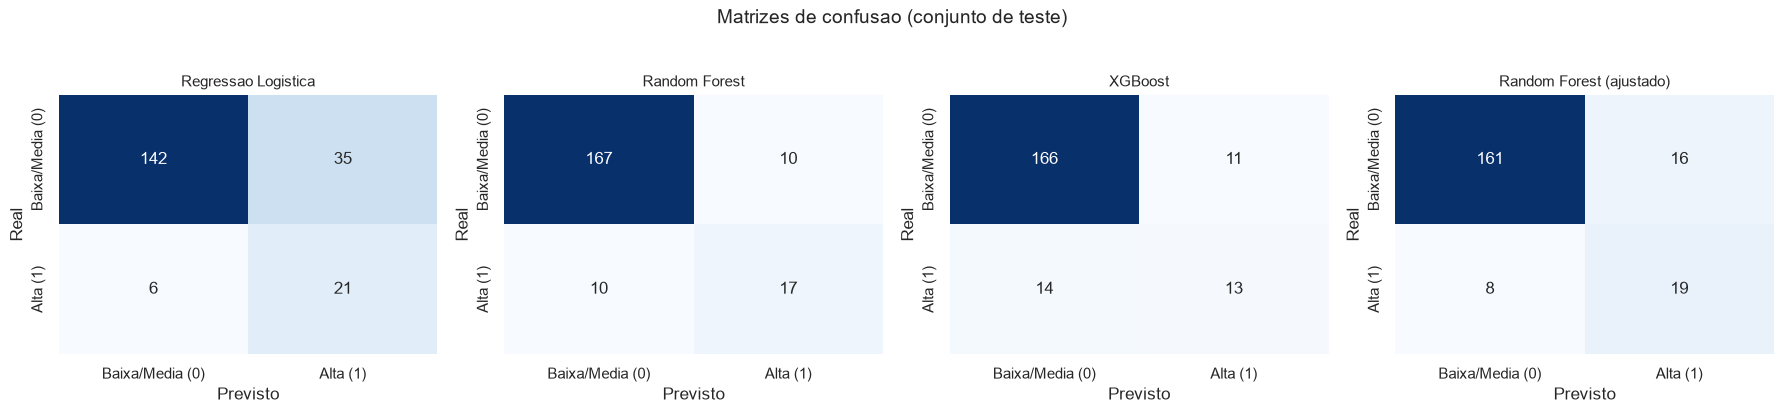

In [24]:
path = ev.plot_confusion_matrices(preds, y_test, RESULTS_DIR)
print('Grafico salvo em:', path.relative_to(PROJECT_ROOT))

**Como ler:** linhas = classe real, colunas = classe prevista. Como usamos **aprendizado sensivel ao custo**, os modelos priorizam **recall** da classe positiva - espera-se **poucos falsos negativos** (canto superior direito baixo), ao custo de alguns **falsos positivos** (vinhos comuns classificados como alta qualidade). Esse trade-off e desejavel quando o objetivo e **nao deixar passar** um vinho de alta qualidade.

### 5.4 Curvas ROC

Grafico salvo em: results\avaliacao_curvas_roc.png


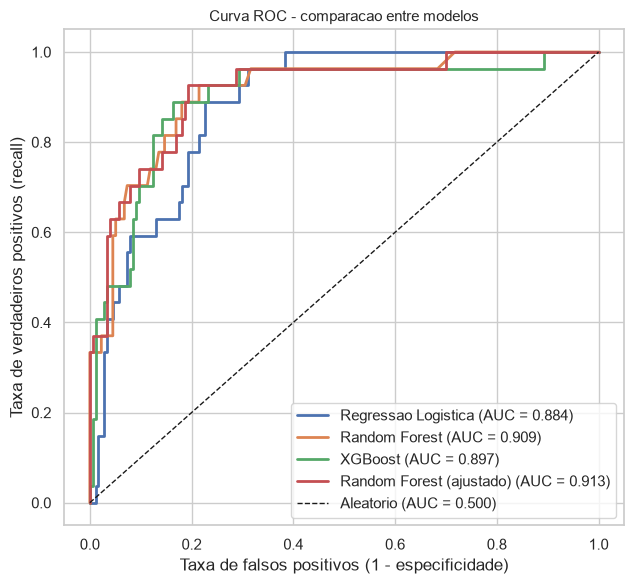

In [25]:
path = ev.plot_roc_curves(preds, y_test, RESULTS_DIR)
print('Grafico salvo em:', path.relative_to(PROJECT_ROOT))

**Como ler:** quanto mais a curva se aproxima do canto superior esquerdo, melhor; a diagonal representa um classificador aleatorio (AUC = 0,5). A AUC resume a capacidade de **ranquear** um positivo acima de um negativo, independentemente do limiar escolhido.

### 5.5 Curvas Precision-Recall

Grafico salvo em: results\avaliacao_curvas_precision_recall.png


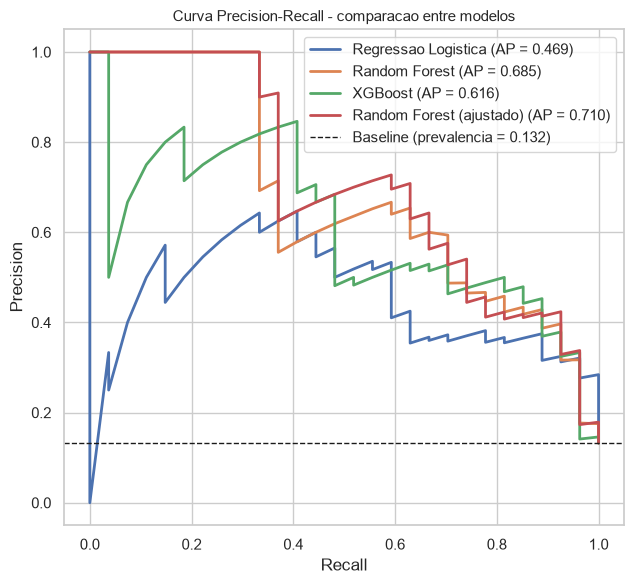

In [26]:
path = ev.plot_pr_curves(preds, y_test, RESULTS_DIR)
print('Grafico salvo em:', path.relative_to(PROJECT_ROOT))

**Como ler:** sob forte desbalanceamento, a curva Precision-Recall e **mais informativa** que a ROC. A linha de base tracejada e a **prevalencia** da classe positiva no teste (~13%); curvas bem acima dessa linha indicam que o modelo extrai sinal real sobre a classe rara. A **PR-AUC (AP)** e a metrica que melhor diferencia os modelos aqui.

### 5.6 Ajuste do limiar de decisao

O limiar padrao de 0,5 nao e necessariamente o melhor ponto de operacao sob desbalanceamento. Selecionamos o **melhor modelo** (topo da tabela por F1) e buscamos o **limiar otimo para F1 por validacao cruzada no treino** - usando probabilidades **out-of-fold**, que sao realistas (sem o otimismo de prever no proprio treino) e **nao tocam no teste**. Em seguida comparamos, **no teste**, o ponto de operacao padrao (0,5) com o ajustado.

In [27]:
best_name = tabela_comparativa.index[0]
best_model = fitted[best_name]

# Limiar otimo p/ F1 via probabilidades out-of-fold no treino (realista, sem tocar no teste)
best_t, best_f1_cv = ev.tune_threshold_cv(best_model, X_train_scaled, y_train, metric='f1', cv=5)
print(f'Modelo selecionado (melhor F1): {best_name}')
print(f'Limiar otimo p/ F1 (validacao cruzada no treino): {best_t:.3f}  (F1 CV = {best_f1_cv:.3f})')

# Ponto de operacao no TESTE: limiar padrao vs ajustado por CV
proba_test = preds[best_name]['proba']
op_default = ev.evaluate_at_threshold(y_test, proba_test, 0.5)
op_tuned = ev.evaluate_at_threshold(y_test, proba_test, best_t)
pd.DataFrame(
    [op_default, op_tuned],
    index=['Limiar 0.50 (padrao)', f'Limiar {best_t:.2f} (ajustado por CV)'],
).round(4)

Modelo selecionado (melhor F1): Random Forest
Limiar otimo p/ F1 (validacao cruzada no treino): 0.465  (F1 CV = 0.568)


,threshold,accuracy,precision,recall,f1
Limiar 0.50 (padrao),0.500,0.9020,0.6296,0.6296,0.6296
Limiar 0.46 (ajustado por CV),0.465,0.8971,0.6000,0.6667,0.6316


**Leitura:** baixar o limiar (para um pouco abaixo de 0,5) **aumenta o recall** (captura mais vinhos de alta qualidade) com uma leve melhora de F1, ao custo de um pouco de precision. E a alavanca de negocio: se o objetivo for **nao perder** bons vinhos, opera-se num limiar mais baixo; se falsos alarmes forem caros, mantem-se 0,5 ou acima.

### Resumo da avaliacao

- **4 modelos** avaliados no conjunto de teste (204 amostras, 27 positivas).
- **Melhor F1/accuracy:** Random Forest (F1 ~0,63; accuracy ~0,90).
- **Melhor ROC-AUC/PR-AUC:** Random Forest ajustado (~0,91 e ~0,71) - melhor ranqueamento e desempenho na classe rara.
- **Maior recall:** Regressao Logistica (~0,78), com baixa precision.
- Metricas salvas em `results/metricas_modelos.csv` e `.json`; graficos (matrizes de confusao, curvas ROC e Precision-Recall) salvos em `results/`.
- **Ajuste de limiar** por CV demonstrou como calibrar o ponto de operacao (recall vs precision) sem vazamento.

**Recomendacao pratica:** para **priorizar/ranquear** amostras, usar o **Random Forest ajustado** (melhor AUC/PR-AUC); para uma **decisao binaria equilibrada**, o Random Forest padrao; para **maximizar a captura** de bons vinhos, reduzir o limiar ou adotar a Regressao Logistica.

## 6. Interpretacao dos resultados

Alem de prever, queremos **entender** quais variaveis fisico-quimicas mais influenciam a qualidade. Analisamos a importancia das variaveis por duas oticas complementares:

- **Arvores (Random Forest e XGBoost):** importancia por **reducao de impureza** - magnitude sempre positiva, capturando efeitos nao lineares e interacoes.
- **Regressao Logistica:** **coeficientes com sinal** - indicam a **direcao** do efeito (aumenta ou diminui a chance de alta qualidade) e sao diretamente comparaveis porque as variaveis estao padronizadas.

Todos os graficos sao salvos em `results/`.

### 6.1 Importancia das variaveis - Random Forest

Grafico salvo em: results\interpretacao_importancia_rf.png


alcohol                 0.1513
alcohol_sulphates       0.1496
volatile acidity        0.1026
fixed_volatile_ratio    0.0798
sulphates               0.0771
density                 0.0606
citric acid             0.0588
chlorides               0.0575
free_sulfur_ratio       0.0545
total sulfur dioxide    0.0526
fixed acidity           0.0452
free sulfur dioxide     0.0383
pH                      0.0368
residual sugar          0.0354
dtype: float64

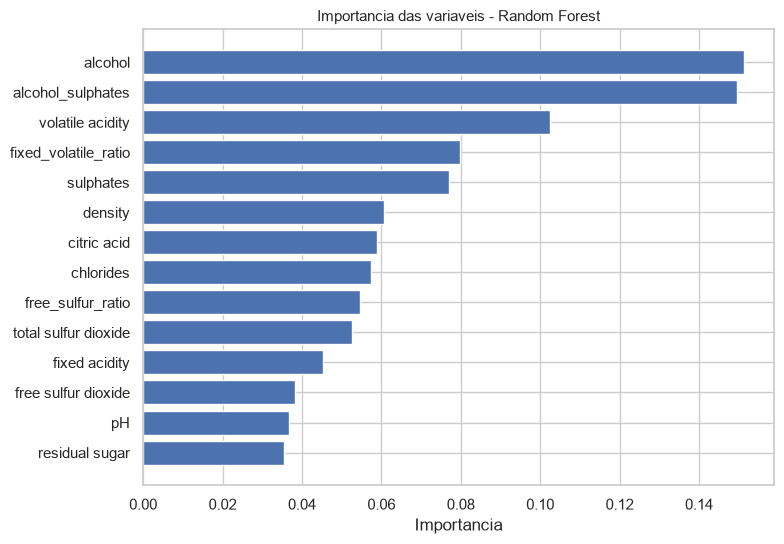

In [28]:
feat_names = X_train_scaled.columns.tolist()
rf_importance = ev.get_feature_importance(fitted['Random Forest'], feat_names)
path = ev.plot_feature_importance(
    rf_importance, 'Importancia das variaveis - Random Forest',
    RESULTS_DIR, 'interpretacao_importancia_rf.png'
)
print('Grafico salvo em:', path.relative_to(PROJECT_ROOT))
rf_importance.sort_values(ascending=False).round(4)

### 6.2 Importancia das variaveis - XGBoost

Grafico salvo em: results\interpretacao_importancia_xgb.png


alcohol_sulphates       0.1961
alcohol                 0.1676
volatile acidity        0.0926
fixed_volatile_ratio    0.0879
chlorides               0.0630
free_sulfur_ratio       0.0574
total sulfur dioxide    0.0529
pH                      0.0450
citric acid             0.0442
free sulfur dioxide     0.0439
fixed acidity           0.0410
density                 0.0404
residual sugar          0.0362
sulphates               0.0318
dtype: float32

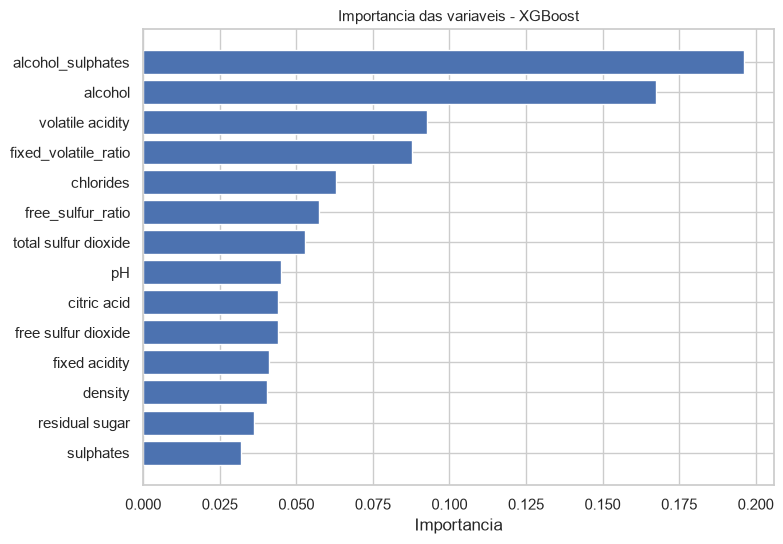

In [29]:
xgb_importance = ev.get_feature_importance(fitted['XGBoost'], feat_names)
path = ev.plot_feature_importance(
    xgb_importance, 'Importancia das variaveis - XGBoost',
    RESULTS_DIR, 'interpretacao_importancia_xgb.png'
)
print('Grafico salvo em:', path.relative_to(PROJECT_ROOT))
xgb_importance.sort_values(ascending=False).round(4)

### 6.3 Coeficientes da Regressao Logistica

Grafico salvo em: results\interpretacao_coeficientes_logreg.png


alcohol                 0.8695
sulphates               0.6430
fixed acidity           0.5879
free_sulfur_ratio       0.5170
residual sugar          0.3814
alcohol_sulphates       0.1303
citric acid             0.0402
free sulfur dioxide    -0.1589
total sulfur dioxide   -0.1868
fixed_volatile_ratio   -0.1997
pH                     -0.2322
chlorides              -0.4394
density                -0.4582
volatile acidity       -0.6979
dtype: float64

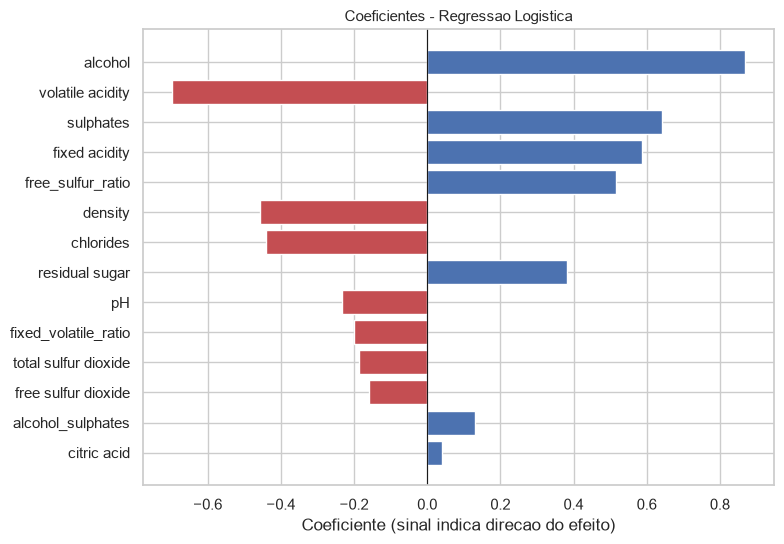

In [30]:
logreg_coef = ev.get_feature_importance(fitted['Regressao Logistica'], feat_names)
path = ev.plot_feature_importance(
    logreg_coef, 'Coeficientes - Regressao Logistica',
    RESULTS_DIR, 'interpretacao_coeficientes_logreg.png', signed=True
)
print('Grafico salvo em:', path.relative_to(PROJECT_ROOT))
logreg_coef.sort_values(ascending=False).round(4)

### 6.4 Discussao consolidada

**Convergencia entre os modelos.** Os tres modelos apontam, de forma consistente, o mesmo pequeno conjunto de variaveis como determinante da qualidade:

| Papel | Variaveis | Evidencia |
|---|---|---|
| **Aumentam** a qualidade | `alcohol`, `sulphates`, `citric acid`, `fixed acidity` | Coeficientes positivos na LogReg; alcool e o #1 nas arvores. |
| **Reduzem** a qualidade | `volatile acidity`, `density`, `chlorides` | volatile acidity e o coeficiente negativo mais forte (~ -0,70) e o #3 nas arvores. |

**Destaques por modelo:**
- **Random Forest e XGBoost** concordam no **top 4**: `alcohol`, `alcohol_sulphates`, `volatile acidity` e `fixed_volatile_ratio`.
- **Regressao Logistica** confirma as direcoes: `alcohol` (~ +0,87) e `sulphates` (~ +0,64) puxam para cima; `volatile acidity` (~ -0,70), `density` (~ -0,46) e `chlorides` (~ -0,44) puxam para baixo.

**As features derivadas se pagaram.** Duas das tres variaveis criadas aparecem no **top 4 de ambas as arvores**:
- **`alcohol_sulphates`** (interacao corpo x conservante) e a **1a no XGBoost** e a 2a no Random Forest;
- **`fixed_volatile_ratio`** (acidez 'boa' vs. 'ruim') e a **4a em ambas**.

Isso **valida empiricamente a engenharia de atributos**: elas resumiram interacoes uteis que os modelos de fato aproveitaram.

**Coerencia enologica.** O retrato bate com o conhecimento de vinificacao e com a EDA (secao 2):
- **alcool alto** (uvas maduras, vinho mais encorpado) e o maior marcador de qualidade;
- **acidez volatil alta** (acido acetico, aroma avinagrado) e o maior indicador de defeito;
- **sulfatos** em boa dosagem preservam o vinho; **densidade** menor acompanha maior teor alcoolico.

Nota interessante: `free_sulfur_ratio` tem coeficiente **positivo** na LogReg, enquanto o SO2 total isolado e negativo - coerente, pois o que protege o vinho e a **fracao livre/ativa** do SO2, nao o total.

### Resumo da interpretacao

- Variaveis mais influentes: **alcohol**, **volatile acidity** e **sulphates**, alem das derivadas **alcohol_sulphates** e **fixed_volatile_ratio**.
- Direcao dos efeitos (LogReg): alcool / sulfatos / acido citrico **aumentam** a chance de alta qualidade; acidez volatil / densidade / cloretos **reduzem**.
- **Feature engineering validada**: 2 das 3 variaveis criadas estao entre as mais importantes das arvores.
- Achados **coerentes com a EDA** (correlacoes) e com a **enologia**.
- Graficos salvos em `results/`: importancia (RF e XGBoost) e coeficientes (LogReg).

## Conclusao

Este notebook percorreu o **pipeline completo** de classificacao binaria da qualidade de vinhos:

1. **Compreensao e EDA:** 1143 amostras, 11 variaveis fisico-quimicas; desbalanceamento ~6:1 (so ~14% de alta qualidade) e variaveis-chave identificadas (alcool, acidez volatil, sulfatos).
2. **Pre-processamento sem vazamento:** remocao de 125 duplicatas, capping de outliers e padronizacao **ajustados apenas no treino**, mais **3 features derivadas** com base enologica.
3. **Modelagem:** 3 familias de modelos (Regressao Logistica, Random Forest, XGBoost) com tratamento de desbalanceamento (`class_weight`/`scale_pos_weight`, justificado vs. SMOTE por CV) e **GridSearchCV** no Random Forest.
4. **Avaliacao** com metricas adequadas ao desbalanceamento (F1, ROC-AUC, PR-AUC): melhor equilibrio no **Random Forest** (F1 ~0,63) e melhor ranqueamento no **Random Forest ajustado** (ROC-AUC ~0,91; PR-AUC ~0,71).
5. **Interpretacao:** **alcool** e **acidez volatil** como principais direcionadores da qualidade, com as features derivadas entre as mais importantes.

**Aplicacao pratica:** o modelo apoia o **controle de qualidade** ao sinalizar, a partir de medidas de laboratorio, quais vinhos tem maior probabilidade de nota alta - com o **limiar de decisao** ajustavel conforme o custo de negocio (priorizar recall para nao perder bons vinhos, ou precision para reduzir falsos alarmes).